# 02c · Further analysis of connected data
Relate the catalog audio correlation matrix to observed playlist connections and artist-credit paths, then verify graph integrity.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'scripts/data_pipeline.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display, Image
import pandas as pd
from scripts.data_pipeline import OUT, REPORTS


In [2]:
from scripts.project_analysis import further_analysis
relationships = further_analysis()

{
  "catalog_track_count": 586672,
  "connected_catalog_track_count": 11265,
  "tracks_without_playlist_history": 894224,
  "tracks_with_multiple_artist_credits": 107357,
  "strongest_catalog_audio_pairs": [
    {
      "feature_a": "energy",
      "feature_b": "loudness",
      "pearson_r": 0.7647349853389
    },
    {
      "feature_a": "energy",
      "feature_b": "acousticness",
      "pearson_r": -0.715411608089864
    },
    {
      "feature_a": "danceability",
      "feature_b": "valence",
      "pearson_r": 0.5281498162795533
    },
    {
      "feature_a": "loudness",
      "feature_b": "acousticness",
      "pearson_r": -0.5194232900554191
    },
    {
      "feature_a": "energy",
      "feature_b": "valence",
      "pearson_r": 0.3722763076257456
    }
  ],
  "playlist_degree_correlations_on_connected_catalog_tracks": [
    {
      "feature": "popularity",
      "pearson_r": 0.3586912988031227,
      "pairwise_n": 11265
    },
    {
      "feature": "spud_popularity",
      

,feature_a,feature_b,pearson_r
0,energy,loudness,0.765
1,energy,acousticness,-0.715
2,danceability,valence,0.528
3,loudness,acousticness,-0.519
4,energy,valence,0.372
5,loudness,instrumentalness,-0.329
6,loudness,valence,0.275
7,danceability,loudness,0.251
8,danceability,acousticness,-0.243
9,danceability,energy,0.242


,feature,pearson_r,pairwise_n
0,popularity,0.359,11265
1,spud_popularity,0.342,11265
2,acousticness,-0.106,11265
3,valence,-0.097,11265
4,danceability,-0.081,11265
5,energy,0.079,11265
6,loudness,0.079,11265
7,duration_ms,0.063,11265
8,instrumentalness,0.052,11265
9,speechiness,-0.036,11265


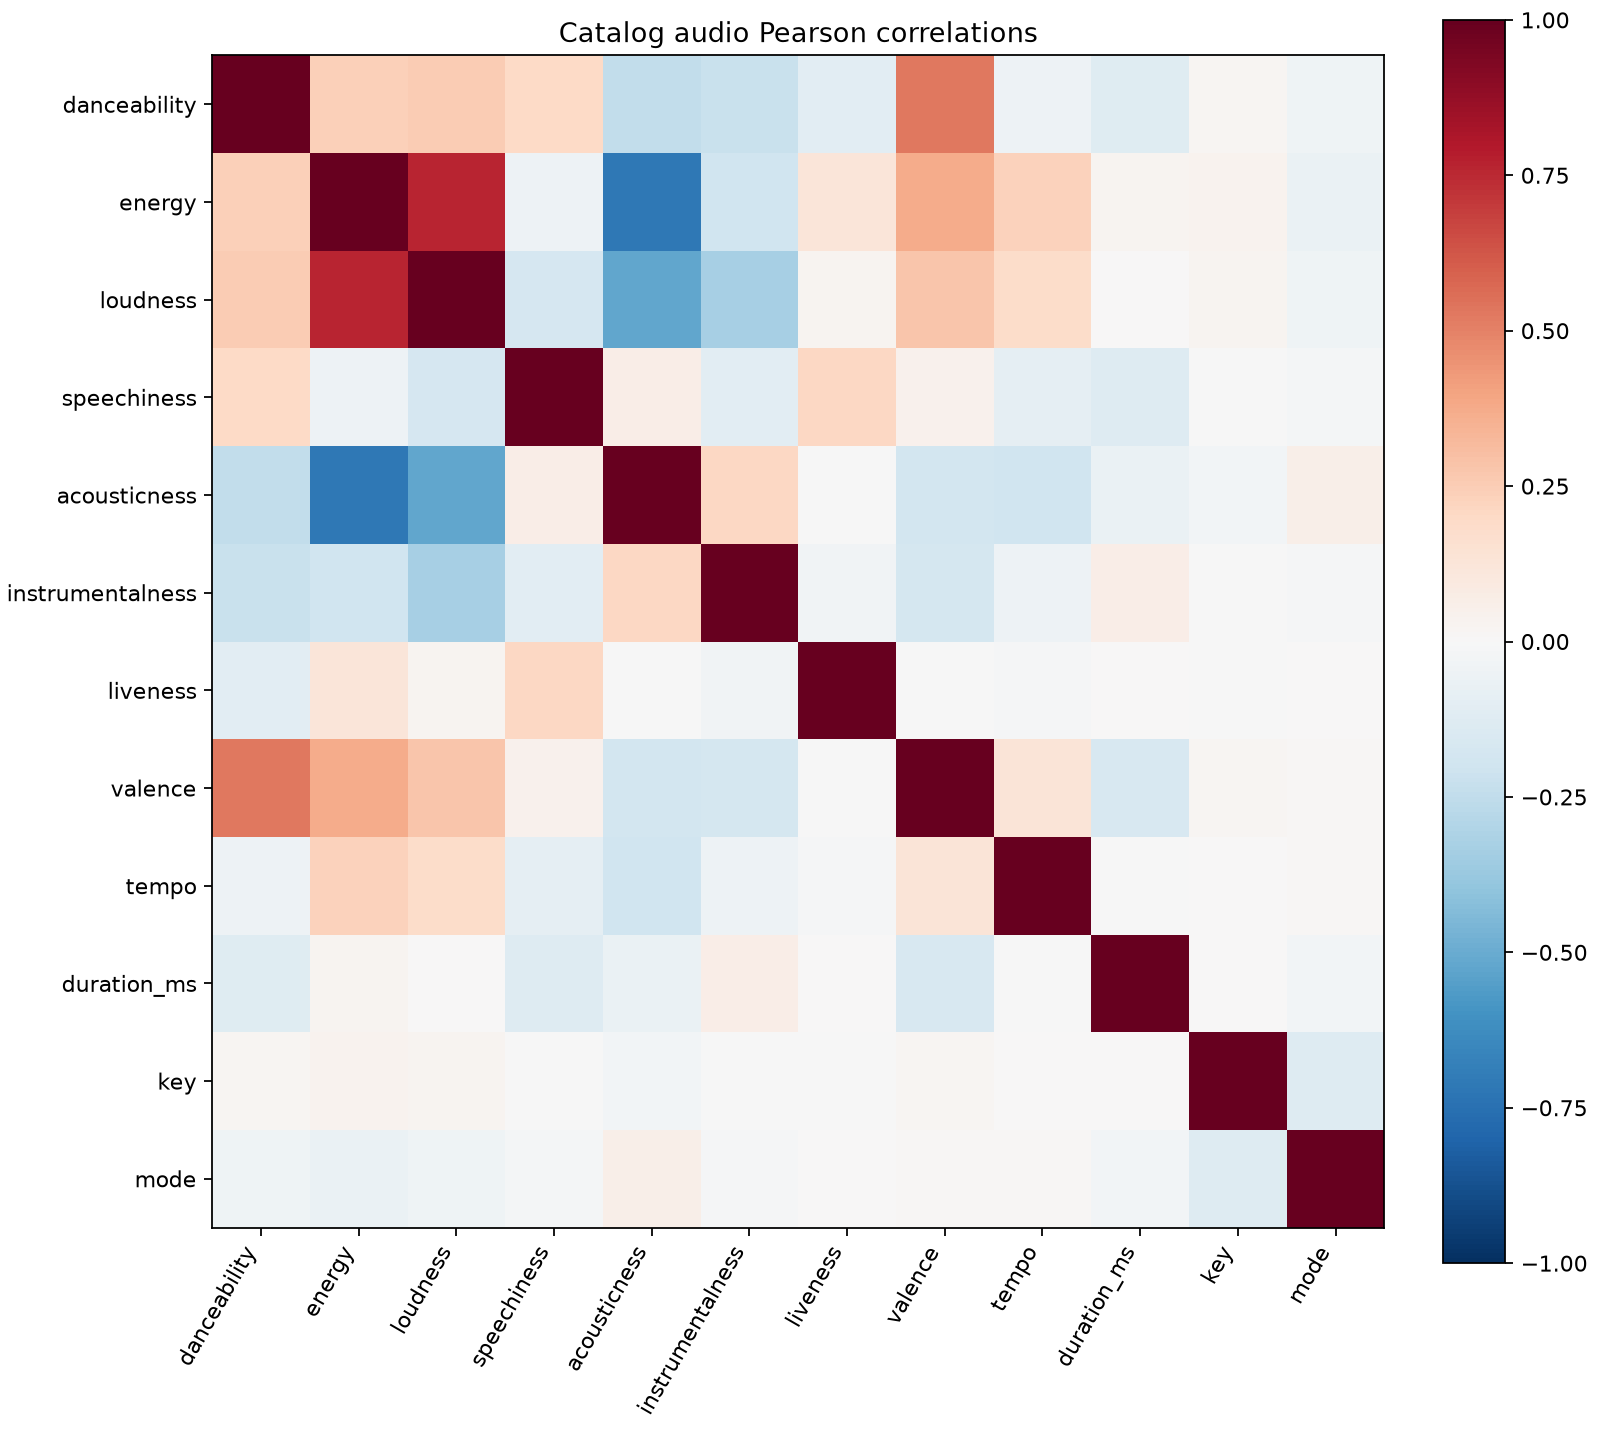

In [3]:
display(pd.read_csv(REPORTS / "catalog_audio_relationships.csv").head(10).round(3))
display(pd.read_csv(REPORTS / "playlist_degree_relationships.csv").head(10).round(3))
display(Image(filename=str(REPORTS / "audio_correlations.png")))

In [4]:
audio = relationships["strongest_catalog_audio_pairs"]
degree = relationships["playlist_degree_correlations_on_connected_catalog_tracks"]
print(f"Strongest catalog audio pair: {audio[0]['feature_a']} and {audio[0]['feature_b']} (r={audio[0]['pearson_r']:.3f}).")
print(f"Among {relationships['connected_catalog_track_count']:,} connected catalog tracks, the strongest playlist-degree relationship is {degree[0]['feature']} (r={degree[0]['pearson_r']:.3f}).")
print(f"The graph also contains {relationships['tracks_with_multiple_artist_credits']:,} tracks with multiple artist credits and {relationships['tracks_without_playlist_history']:,} tracks with no observed playlist history.")

Strongest catalog audio pair: energy and loudness (r=0.765).
Among 11,265 connected catalog tracks, the strongest playlist-degree relationship is popularity (r=0.359).
The graph also contains 107,357 tracks with multiple artist credits and 894,224 tracks with no observed playlist history.


The catalog matrix describes associations between audio features across catalog tracks. The playlist-degree table uses only catalog tracks connected to observed playlists, with pairwise sample sizes reported. Compare the direction and magnitude of these relationships, then examine coverage and multi-artist credits as graph paths. Correlation does not establish causation or model quality; missing playlist membership is missing observation, not negative preference.

In [5]:
from scripts.project_analysis import diagnostics
checks = diagnostics()

{
  "unique_track_ids": true,
  "unique_edges": true,
  "valid_endpoints": true,
  "finite_graph_features": true,
  "disjoint_splits": true,
  "full_catalog_retained": true,
  "exposure_gini_including_catalog_only": 0.8411020079276328,
  "country_metadata_rows": 0,
  "cold_start_limitation": "Catalog-only tracks can be scored, but absent playlist ground truth cannot establish their recommendation quality. No playlist memberships are fabricated."
}


The integrity checks verify identities, graph endpoints and finite propagated features. Artist credits and genre links connect tracks even when playlist history is absent; these paths support scoring but cannot prove recommendation quality without held-out playlist labels.